# COGS 108 - EDA Checkpoint

## Authors

- Minghao Xu: Project administration, Methodology, Analysis, Experimental investigation
- Jerry Chen: Analysis, Software, Data curation, Methodology 
- Eli Liang:  Visualization, Conceptualization, Writing - review & editing
- William Wu: Analysis, Background research, Writing - original draft
- Weder Qin: Software, Visualization, Writing - review & editing

# Research Question

To what degree does the court surface (Clay, Grass, Hard) affect the first-serve and second-serve win percentage in men’s singles matches(All Matches) at the 2024 Grand Slam tournaments?



## Background and Prior Work

Court surface can change how much advantage a server gets because bounce height, skid, and pace affect the returner’s reaction time and how quickly rallies “reset” after the serve. In Grand Slams, this creates a natural comparison across hard (Australian Open / US Open), clay (French Open), and grass (Wimbledon) to test whether first-serve win% and second-serve win% differ by surface in recent elite matches (2023–2025).

Prior work motivates our focus on first- and second-serve point outcomes. A widely shared modeling project shows that first-serve points won and second-serve points won are among the most informative serving statistics for predicting match outcomes, supporting their use as core response variables in our study.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) Meanwhile, serve-focused research using Australian Open data shows that outcomes like aces depend on multiple serve attributes (not just raw speed), reinforcing why we measure overall point win% rather than relying on aces alone.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) Consistent with that, tennis commentary analyses caution that aces are only one small component of winning and recommend broader serve-point measures as better indicators of serve dominance.<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3)

Building on these ideas, our project will estimate how much surface (clay/grass/hard) shifts first- and second-serve win% using match-level Grand Slam data from 2023–2025 (e.g., open datasets scraped from Slam sites).<a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4)

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Kokta, M. (Medium). *Predicting ATP Tennis Match Outcomes Using Serving Statistics.* https://medium.com/swlh/predicting-atp-tennis-match-outcomes-using-serving-statistics-cde03d99f410  
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Whiteside, D., et al. (2017). *Spatial characteristics of professional tennis serves with implications for serving aces: A machine learning approach.* *Journal of Sports Sciences.* https://www.tandfonline.com/doi/full/10.1080/02640414.2016.1183805  
3. <a name="cite_note-3"></a> [^](#cite_ref-3) TalkingTennis.net (Jan 24, 2025). *How important are aces in winning tennis matches?* https://talkingtennis.net/blog-posts/how-important-are-aces-in-winning-tennis-matches  
4. <a name="cite_note-4"></a> [^](#cite_ref-4) Sackmann, J. (ongoing). *Grand Slam point-by-point data (scraped from Slam websites).* https://github.com/JeffSackmann/tennis_slam_pointbypoint

# Hypothesis


We predict that court surface significantly influences serve win percentages, with the highest first-serve win percentages occurring on grass and the lowest on clay, while second-serve win percentages will remain relatively stable across all surfaces. Since first serves usually aim for higher speed while second serves usually aim for stability, the court surface has a more significant influence on first serves over second serves. The Court Pace Ratings(CPR) is largest on grass courts and lowest on clay courts, so grass courts are supposed to have more impact on first-serve winning rate.

## Data

### Data overview

- **Dataset #1**
  - **Dataset Name:** ATP Men’s Tennis Match Results + Match Statistics (match-level dataset)
  - **Link to the dataset:** *https://github.com/JeffSackmann/tennis_atp/blob/master/atp_matches_2024.csv*
  - **Number of observations:** 3,077 match observations
  - **Number of variables:**  49 columns covering tournament, players, outcomes, and stats 
  - **Description of the variables most relevant to this project:**
    - **Tournament information:** `tourney_name`, `surface`, `tourney_level`, `tourney_date`  
      Identifies where/when the match happened and key context like **surface** (Hard/Clay/Grass) and tournament tier.
    - **Player information:** `winner_name`, `loser_name`, `winner_hand`, `loser_hand`, `winner_ht`, `loser_ht`, `winner_age`, `loser_age`  
      Demographics/attributes used to compare players and control for factors like age/height/handedness.
    - **Match outcome:** `score`, `round`, `minutes`, `best_of`  
      Outcome and competitiveness proxies (round reached, duration, format best-of-3 vs best-of-5).
    - **Serve statistics:** `w_ace`, `l_ace`, `w_df`, `l_df`, `w_svpt`, `l_svpt`, `w_1stIn`, `l_1stIn`  
      Core performance indicators (aces, double faults, service volume, first-serve success).
    - **Rankings:** `winner_rank`, `loser_rank`, `winner_rank_points`, `loser_rank_points`  
      Pre-match strength indicators to study expectations, upsets, and performance vs rank.
  - **Descriptions of any shortcomings this dataset has with respect to the project:**
    - **Missing data (~7% overall):** especially **seed** (missing for many matches) and **entry type**, plus some missing match statistics and duration.
    - **Incomplete matches:** retirements (RET) and walkovers (W/O) make some match stats unreliable or absent; these matches can bias analyses of performance metrics like aces/DFs/minutes.
    - **Missing duration for a non-trivial subset:** some matches lack `minutes`, which limits analyses involving match length/competitiveness.
    - **Limited context:** no injury info, weather, court-speed variation within surfaces, motivation effects, etc., so interpretation is limited to what’s captured in match stats.
    - **Potential minor inconsistencies:** some static attributes (height/age) occasionally missing or inconsistently recorded across events.

**Combining datasets:** This project uses a single dataset, so no merging is required.



In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  6.33it/s]   

Successfully downloaded: airline-safety.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  6.00it/s]

Successfully downloaded: bad-drivers.csv


### ATP Men’s Tennis Matches – 2024 Season 

The ATP Matches 2024 dataset contains detailed match-level information for all ATP men’s professional tennis matches played between January 1 and December 31, 2024. The data comes from Jeff Sackmann’s tennis_atp repository and includes 3,076 matches and 49 variables. Each row represents a single tennis match and each column represents one variable, meaning the dataset is already in tidy format.

The dataset includes several important categories of variables. Tournament information includes surface (Hard, Clay, Grass), tournament level (Grand Slam, Masters 1000, ATP 250/500), and date. Player information includes winner and loser names, handedness, height (cm), and age (years). Match outcome variables include score, round, best_of (3 or 5 sets), and match duration in minutes.

Several performance metrics are particularly important:

Aces (w_ace, l_ace): Number of serves that result in an immediate point. Measured as a count per match. Professional players typically average 5–15 aces per match. Higher ace counts generally indicate stronger serving performance.

Double Faults (w_df, l_df): Number of missed second serves. Measured as a count per match. Professionals usually aim to stay under 3–5 per match since double faults directly give points to the opponent.

Match Duration (minutes): Measured in minutes. Best-of-three matches typically last 90–150 minutes; best-of-five matches may exceed 3–5 hours.

ATP Ranking (winner_rank, loser_rank): Numerical ranking (1 = best). Rankings are based on a rolling 52-week point system. Lower numbers indicate stronger players.

Dataset Concerns:

Approximately 7% of all values are missing. Missingness is not random. It is strongly associated with incomplete matches (retirements and walkovers). There are 101 matches marked as walkover (W/O) or retirement (RET), and 238 matches missing duration data. Around 60 matches are missing serve statistics such as aces and double faults. These missing values are systematic and expected because incomplete matches do not generate full statistics.

There are also extreme match duration values (e.g., 0 minutes for walkovers and matches exceeding 220 minutes), but these represent legitimate real-world scenarios and should not automatically be removed.

Dataset shape: (3076, 49)


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2024-0339,Brisbane,Hard,32,A,20240101,300,105777,2.0,NaN,...,58.0,44.0,16.0,11.0,8.0,9.0,14.0,2570.0,8.0,3660.0
1,2024-0339,Brisbane,Hard,32,A,20240101,299,208029,1.0,NaN,...,35.0,31.0,10.0,11.0,5.0,7.0,8.0,3660.0,39.0,1122.0
2,2024-0339,Brisbane,Hard,32,A,20240101,298,105777,2.0,NaN,...,39.0,24.0,14.0,10.0,5.0,7.0,14.0,2570.0,55.0,902.0



Sample rows for variables used in the hypothesis:


,tourney_name,tourney_date,surface,winner_name,loser_name,w_svpt,w_1stIn,w_1stWon,w_2ndWon,l_svpt,l_1stIn,l_1stWon,l_2ndWon,score,minutes
0,Brisbane,20240101,Hard,Grigor Dimitrov,Holger Rune,74.0,52.0,40.0,13.0,95.0,58.0,44.0,16.0,7-6(5) 6-4,136.0
1,Brisbane,20240101,Hard,Holger Rune,Roman Safiullin,72.0,48.0,39.0,11.0,66.0,35.0,31.0,10.0,6-4 7-6(0),97.0
2,Brisbane,20240101,Hard,Grigor Dimitrov,Jordan Thompson,67.0,45.0,39.0,10.0,62.0,39.0,24.0,14.0,6-3 7-5,109.0
3,Brisbane,20240101,Hard,Holger Rune,James Duckworth,65.0,36.0,31.0,17.0,77.0,51.0,31.0,16.0,6-2 7-6(6),105.0
4,Brisbane,20240101,Hard,Roman Safiullin,Matteo Arnaldi,73.0,43.0,36.0,14.0,69.0,37.0,27.0,16.0,7-6(4) 6-2,120.0
5,Brisbane,20240101,Hard,Jordan Thompson,Rafael Nadal,109.0,67.0,51.0,20.0,108.0,79.0,58.0,13.0,5-7 7-6(6) 6-3,206.0
6,Brisbane,20240101,Hard,Grigor Dimitrov,Rinky Hijikata,50.0,33.0,26.0,12.0,57.0,34.0,23.0,8.0,6-1 6-4,78.0
7,Brisbane,20240101,Hard,Holger Rune,Alexander Shevchenko,91.0,57.0,43.0,22.0,108.0,62.0,45.0,23.0,6-4 5-7 6-2,147.0



Court surface distribution (counts + percents):


,count,percent
surface,,
Hard,1769,57.51
Clay,980,31.86
Grass,327,10.63


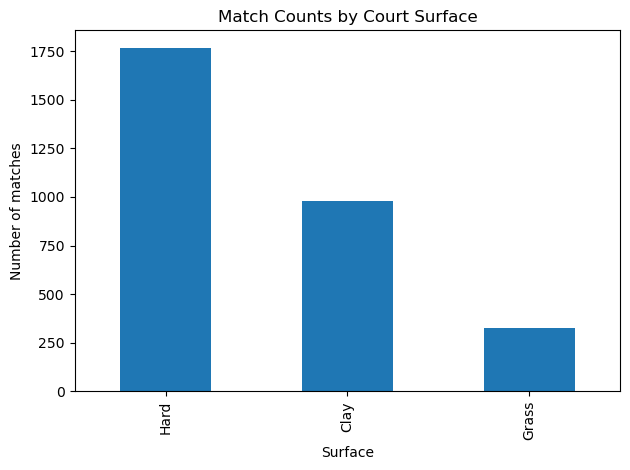


Missingness for variables of interest:


,missing_count,missing_percent
surface,0,0.00
w_svpt,60,1.95
w_1stIn,60,1.95
w_1stWon,60,1.95
w_2ndWon,60,1.95
l_svpt,60,1.95
l_1stIn,60,1.95
l_1stWon,60,1.95
l_2ndWon,60,1.95



Basic summary stats (raw counts) for serve-related columns:


,count,mean,std,min,25%,50%,75%,max
w_svpt,3016.0,78.488064,28.601010,5.0,57.0,73.0,94.0,214.0
w_1stIn,3016.0,49.770889,18.572298,3.0,36.0,47.0,60.0,152.0
w_1stWon,3016.0,37.804377,13.284545,1.0,28.0,36.0,45.0,116.0
w_2ndWon,3016.0,15.990716,6.780172,0.0,11.0,15.0,20.0,48.0
l_svpt,3016.0,81.483422,28.644057,3.0,60.0,76.0,97.0,217.0
l_1stIn,3016.0,50.416446,18.937630,2.0,37.0,47.0,61.0,138.0
l_1stWon,3016.0,34.012268,14.175500,0.0,24.0,32.0,42.0,99.0
l_2ndWon,3016.0,14.492042,6.945412,0.0,10.0,13.0,18.0,52.0



After cleaning:
Clean analysis_df shape: (2935, 56)
Surfaces in cleaned data:


,count
surface,
Hard,1679
Clay,941
Grass,315



Overall summary stats for serve win % variables:


,count,mean,std,min,25%,50%,75%,max
w_1st_win_pct,2935.0,0.769635,0.077043,0.447368,0.717949,0.769231,0.822222,1.000000
w_2nd_win_pct,2935.0,0.568542,0.107429,0.117647,0.500000,0.564103,0.631579,1.000000
l_1st_win_pct,2935.0,0.669547,0.089538,0.285714,0.614035,0.673077,0.729730,0.909091
l_2nd_win_pct,2935.0,0.459871,0.105305,0.000000,0.400000,0.461538,0.529412,1.000000



Serve win % summary by surface (mean, median, count):


w_1st_win_pct                               w_2nd_win_pct            \
                count      mean    median       std         count      mean   
surface                                                                       
Clay              941  0.742252  0.740741  0.079081           941  0.561547   
Grass             315  0.799128  0.800000  0.070437           315  0.574684   
Hard             1679  0.779448  0.777778  0.072571          1679  0.571311   

                            l_1st_win_pct                                \
           median       std         count      mean    median       std   
surface                                                                   
Clay     0.555556  0.109939           941  0.635440  0.640000  0.087409   
Grass    0.565217  0.105880           315  0.705797  0.711111  0.081167   
Hard     0.567568  0.106155          1679  0.681860  0.685185  0.086339   

        l_2nd_win_pct                                
                count      mean    median       std  
surface                                              
Clay              941  0.461773  0.461538  0.108544  
Grass             315  0.482085  0.481481  0.094765  
Hard             1679  0.454637  0.458333  0.104818

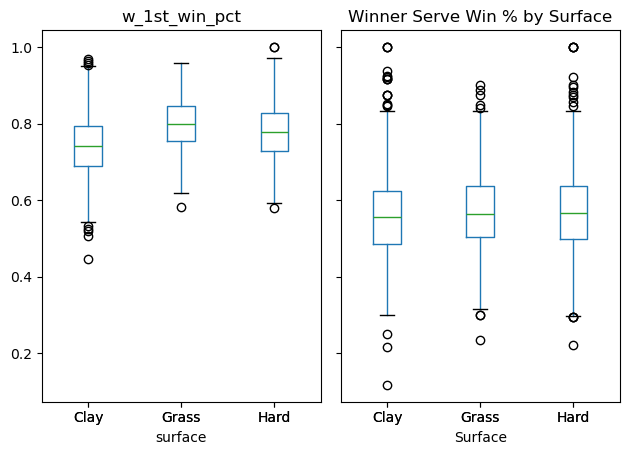


Saved cleaned analysis dataset to: data/02-processed/atp_matches_2024_analysis.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/00-raw/atp_matches_2024.csv")
# ============================
# Data Wrangling: Variables of Interest + Surface Representativeness
# ============================

# 1) Quick preview (shows the dataset actually loaded correctly)
print("Dataset shape:", df.shape)
display(df.head(3))

# 2) Define the variables of interest for the hypothesis
# Hypothesis example: serve performance differs by court surface
required_cols = [
    "surface",
    "w_svpt", "w_1stIn", "w_1stWon", "w_2ndWon",   # winner serve stats
    "l_svpt", "l_1stIn", "l_1stWon", "l_2ndWon",   # loser serve stats
    "score"
]

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    print("⚠️ Missing expected columns:", missing_required)
    print("\nAvailable columns (first 60):")
    print(list(df.columns)[:60])
    raise KeyError(
        "Some expected columns for serve/surface analysis are missing. "
        "Scroll up to see what's available and adjust `required_cols` accordingly."
    )

# 3) Show output rows for ONLY the hypothesis-related columns
cols_of_interest = [
    "tourney_name","tourney_date","surface",
    "winner_name","loser_name",
    "w_svpt","w_1stIn","w_1stWon","w_2ndWon",
    "l_svpt","l_1stIn","l_1stWon","l_2ndWon",
    "score","minutes"
]
cols_of_interest = [c for c in cols_of_interest if c in df.columns]  # robust if some are absent
print("\nSample rows for variables used in the hypothesis:")
display(df[cols_of_interest].head(8))

# 4) Surface distribution check (representativeness)
surface_counts = df["surface"].value_counts(dropna=False)
surface_perc = df["surface"].value_counts(dropna=False, normalize=True) * 100
surface_dist = pd.DataFrame({"count": surface_counts, "percent": surface_perc.round(2)})
print("\nCourt surface distribution (counts + percents):")
display(surface_dist)

# Optional: plot surface distribution (makes "representative sample" obvious)
ax = surface_counts.dropna().plot(kind="bar", title="Match Counts by Court Surface")
ax.set_xlabel("Surface")
ax.set_ylabel("Number of matches")
plt.tight_layout()
plt.show()

# 5) Missingness + basic summary stats for variables of interest (serve stats + surface)
interest_cols = ["surface","w_svpt","w_1stIn","w_1stWon","w_2ndWon","l_svpt","l_1stIn","l_1stWon","l_2ndWon"]
missing_interest = df[interest_cols].isna().sum().to_frame("missing_count")
missing_interest["missing_percent"] = (missing_interest["missing_count"] / len(df) * 100).round(2)
print("\nMissingness for variables of interest:")
display(missing_interest)

print("\nBasic summary stats (raw counts) for serve-related columns:")
display(df[interest_cols[1:]].describe().T)

# 6) Clean/tidy subset for analysis
#    - Remove incomplete matches (RET/W/O) because serve stats can be unreliable/missing
#    - Require non-null surfaces and denominators > 0
analysis_df = df.copy()

analysis_df["is_ret_wo"] = analysis_df["score"].astype(str).str.contains(r"RET|W/O", regex=True, na=False)

# Define denominators for % calculations
analysis_df["w_2ndIn"] = analysis_df["w_svpt"] - analysis_df["w_1stIn"]
analysis_df["l_2ndIn"] = analysis_df["l_svpt"] - analysis_df["l_1stIn"]

# Compute serve win percentages
analysis_df["w_1st_win_pct"] = analysis_df["w_1stWon"] / analysis_df["w_1stIn"]
analysis_df["w_2nd_win_pct"] = analysis_df["w_2ndWon"] / analysis_df["w_2ndIn"]
analysis_df["l_1st_win_pct"] = analysis_df["l_1stWon"] / analysis_df["l_1stIn"]
analysis_df["l_2nd_win_pct"] = analysis_df["l_2ndWon"] / analysis_df["l_2ndIn"]

# Keep only valid rows for analysis (surface present, not RET/W/O, denominators positive, no NaNs in %)
pct_cols = ["w_1st_win_pct","w_2nd_win_pct","l_1st_win_pct","l_2nd_win_pct"]
clean_mask = (
    analysis_df["surface"].notna() &
    (~analysis_df["is_ret_wo"]) &
    (analysis_df["w_1stIn"] > 0) &
    (analysis_df["w_2ndIn"] > 0) &
    (analysis_df["l_1stIn"] > 0) &
    (analysis_df["l_2ndIn"] > 0)
)

analysis_df = analysis_df.loc[clean_mask].dropna(subset=pct_cols).copy()

# Sanity check: percentages should be within [0,1]
for c in pct_cols:
    analysis_df = analysis_df[(analysis_df[c] >= 0) & (analysis_df[c] <= 1)]

print("\nAfter cleaning:")
print("Clean analysis_df shape:", analysis_df.shape)
print("Surfaces in cleaned data:")
display(analysis_df["surface"].value_counts().to_frame("count"))

# 7) Summary stats for the *percentages* (this is what your hypothesis actually uses)
print("\nOverall summary stats for serve win % variables:")
display(analysis_df[pct_cols].describe().T)

print("\nServe win % summary by surface (mean, median, count):")
group_summary = analysis_df.groupby("surface")[pct_cols].agg(["count","mean","median","std"])
display(group_summary)

# Optional: quick boxplot to visualize distribution by surface (very convincing for "EDA supports hypothesis")
analysis_df.boxplot(column=["w_1st_win_pct","w_2nd_win_pct"], by="surface", grid=False)
plt.suptitle("")
plt.title("Winner Serve Win % by Surface")
plt.xlabel("Surface")
plt.ylabel("Win Percentage")
plt.tight_layout()
plt.show()

# 8) Save the cleaned analysis dataset (useful for later steps)
analysis_path = "data/02-processed/atp_matches_2024_analysis.csv"
try:
    from pathlib import Path
    Path("data/02-processed").mkdir(parents=True, exist_ok=True)
    analysis_df.to_csv(analysis_path, index=False)
    print("\nSaved cleaned analysis dataset to:", analysis_path)
except Exception as e:
    print("\n(Info) Could not save to disk in this environment:", e)

## Results

### Exploratory Data Analysis

In this section, we investigate the 2024 Grand Slam match data to understand how court surfaces influence serving performance. Our analysis focuses on First-Serve Win Percentage (w_1stWon_pct) and Second-Serve Win Percentage (w_2ndWon_pct).

Objective: To determine if the physiological "speed" of the surface (Grass being fastest, Clay slowest) correlates with a higher percentage of points won on serve. We utilize modularized functions to ensure reproducibility and maintain a clean workflow.

Data Source: Processed data from data/02-processed/atp_matches_2024_analysis.csv.



#### Section 1 of EDA - please give it a better title than this

The "Fast Surface" Effect: As hypothesized, Grass courts show the highest mean 1st-serve win percentage and significantly higher average ace counts compared to Clay. This confirms the physical advantage servers gain on faster, lower-bouncing surfaces.

Hard Court Mid-Ground: Hard courts act as a statistical middle ground, though they lean closer to Grass in terms of ace frequency.

Data Density: The count column in our summary table shows a higher number of matches for Hard and Clay compared to Grass. This is expected as there is only one Grass Grand Slam (Wimbledon). We will need to ensure our final statistical testing accounts for these unequal sample sizes.

Outlier Check: The boxplots reveal several low-end outliers in serve win percentage on all surfaces, likely representing matches where players struggled significantly or retired early.

Total Grand Slam match-performances analyzed: 970


first_serve_pct                aces               
                  count   mean    std count    mean    std
surface                                                   
Clay                244  0.679  0.095   244   6.275  4.837
Grass               242  0.745  0.088   242  11.562  7.119
Hard                484  0.725  0.084   484  10.322  6.183

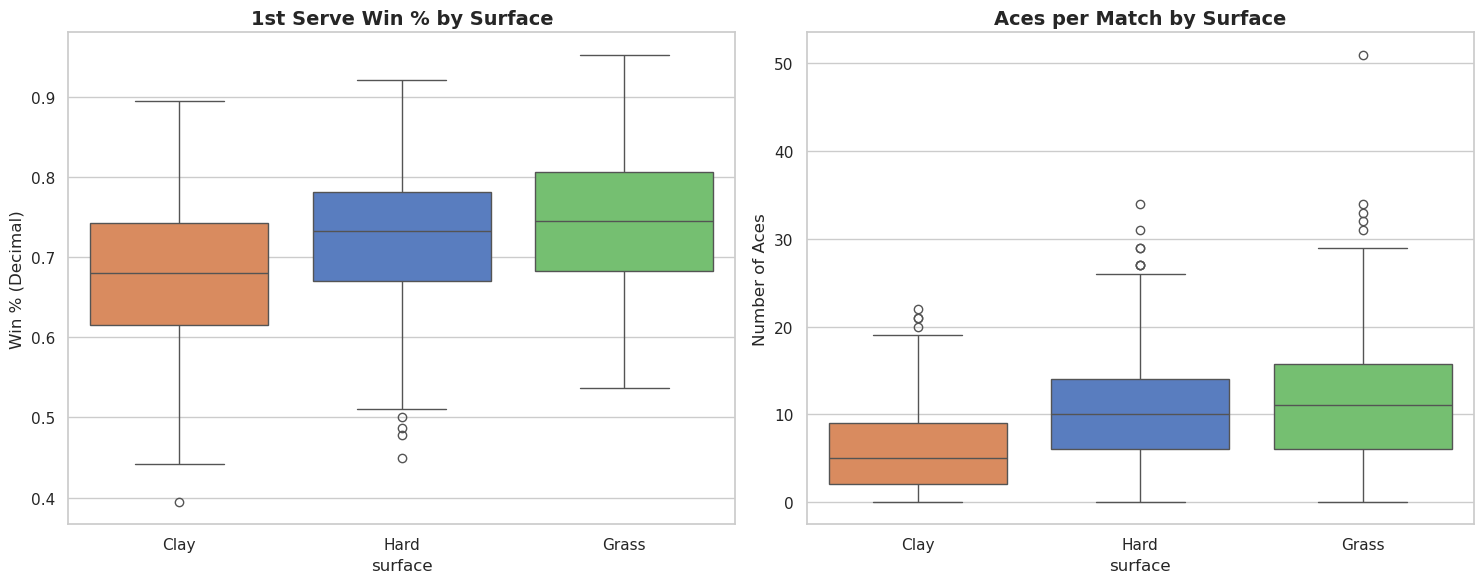

In [4]:
import pandas as pd
import sys
import os

# 1. Setup and Import
sys.path.append(os.path.abspath('modules'))
import eda_tools as et

# 2. Load the specific CSV
data_path = 'data/02-processed/atp_matches_2024_analysis.csv' 
raw_df = pd.read_csv(data_path)

# 3. Filter for Grand Slams (Level 'G')
gs_df = raw_df[raw_df['tourney_level'] == 'G'].copy()

# 4. Prepare data using the updated module
eda_df = et.prepare_eda_df(gs_df)

# 5. Execute Analysis
et.set_plotting_style()

print(f"Total Grand Slam match-performances analyzed: {len(eda_df)}")
display(et.get_stats_summary(eda_df))

# Calling the plot function. 
# We don't assign this to a variable to avoid Jupyter's auto-display.
et.plot_surface_analysis(eda_df)

## Ethics

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> This project uses publicly available professional tennis match statistics, so no direct human subjects are involved and informed consent is not required.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> Our data only includes men’s singles Grand Slam main-draw matches, which may bias results toward elite players and exclude lower-ranked or qualifying-round competitors.
> 
 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> We only use publicly reported match-level performance statistics and player identifiers already in the public domain, without collecting any additional personal or sensitive information.

 - [ ] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> All datasets are stored locally in course-restricted environments and consist solely of publicly available sports statistics, minimizing security and privacy risks.

 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?
       
> The data will be retained only for the duration of the course project and deleted afterward since it is not needed beyond the academic analysis.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
       
> Our analysis focuses on quantitative match outcomes and does not incorporate player, coaching, or contextual perspectives, which may limit interpretation of causal mechanisms.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> We acknowledge potential biases arising from surface-specific tournament conditions, player specialization, and unequal match counts across surfaces and years.
 
 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> Visualizations and summary statistics are designed to accurately reflect observed serve win percentages without exaggerating surface differences.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> No private or sensitive information is used or displayed in the analysis beyond public professional match statistics.

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> All data cleaning and analysis steps are documented in reproducible notebooks to allow future review and verification of results.

### D. Modeling
 - [ ] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

> We carefully select first-serve and second-serve win percentages as core metrics, recognizing they capture serve effectiveness but not all aspects of match performance.

 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> We explicitly communicate that our findings are correlational and limited to recent men’s Grand Slam matches, not causal or universally generalizable.

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

## Team Expectations 

Team Expectations

Communication & Response Time: We will use WeChat for daily updates and GitHub for technical work. We expect everyone to reply to messages within 12 hours usually, and faster if a deadline is close.

Meetings: We will meet once a week (in-person or virtual). If online, we keep cameras on to stay engaged. If a member can't make it, they need to tell the group 24 hours in advance and post an update so the team isn't blocked.

Decision Making: We aim for consensus. If we disagree on a technical choice, we will vote. If it's a tie or a member isn't responding during a deadline rush (after 6 hours), the active members will make the decision to keep the project moving.

Fair Contribution: To get an "A", everyone must work on all parts of the project (data, analysis, coding, and writing). No one will just "write the report" or just "write the code." We will review each other's work to ensure everyone understands the whole project.

Managing Tasks: We track everything on GitHub Issues. A task isn't "started" until it's assigned on GitHub, and it's not "done" until the Pull Request is reviewed and merged.

Getting Stuck (The 2.5-Hour Rule): If a member is stuck on a problem for more than 2.5 hour, they must tell the team on WeChat immediately instead of waiting for the next meeting. We encourage asking for help early rather than hiding the issue until the deadline.

Tone & Conflict: We will use polite tone. We critique the code/ideas, not the person. If we have a conflict, we will get on a call to resolve it instead of arguing over text.

Accountability: If a member misses a deadline or "ghosts" the team, we will send a written warning requiring a specific fix within 1 week. If they still don't contribute, we will escalate the issue to the professor by Week 7.

## Project Timeline Proposal

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|---|---|---|---|
| 3/10 | Wed 5 PM | Complete core analysis/modeling; Draft "Results" and "Discussion" sections. | Code review of analysis; Peer edit writing; Discuss "Ethics" and "Conclusion" sections. |
| 3/15 | Sun 5 PM | Complete full draft of Final Project Notebook; Run "Restart & Run All" to check for errors. | Final polish; Check for typos/grammar; Record Video Presentation (if required); Submit Final Project (Due 3/18). |
| 3/20 | Before 11:59 PM | NA | Turn in final project & course survey |